<a href="https://colab.research.google.com/github/bob-michael-prodmgmt/sandbox/blob/main/CV_Project_Full_Code_Notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Introduction to Computer Vision: Plant Seedlings Classification

## Problem Statement

### Context

In recent times, the field of agriculture has been in urgent need of modernizing, since the amount of manual work people need to put in to check if plants are growing correctly is still highly extensive. Despite several advances in agricultural technology, people working in the agricultural industry still need to have the ability to sort and recognize different plants and weeds, which takes a lot of time and effort in the long term. The potential is ripe for this trillion-dollar industry to be greatly impacted by technological innovations that cut down on the requirement for manual labor, and this is where Artificial Intelligence can actually benefit the workers in this field, as **the time and energy required to identify plant seedlings will be greatly shortened by the use of AI and Deep Learning.** The ability to do so far more efficiently and even more effectively than experienced manual labor, could lead to better crop yields, the freeing up of human inolvement for higher-order agricultural decision making, and in the long term will result in more sustainable environmental practices in agriculture as well.


### Objective

The aim of this project is to Build a Convolutional Neural Netowrk to classify plant seedlings into their respective categories.

### Data Dictionary

The Aarhus University Signal Processing group, in collaboration with the University of Southern Denmark, has recently released a dataset containing **images of unique plants belonging to 12 different species.**

- The dataset can be download from Olympus.
- The data file names are:
    - images.npy
    - Labels.csv
- Due to the large volume of data, the images were converted to the images.npy file and the labels are also put into Labels.csv, so that you can work on the data/project seamlessly without having to worry about the high data volume.

- The goal of the project is to create a classifier capable of determining a plant's species from an image.

**List of Species**

- Black-grass
- Charlock
- Cleavers
- Common Chickweed
- Common Wheat
- Fat Hen
- Loose Silky-bent
- Maize
- Scentless Mayweed
- Shepherds Purse
- Small-flowered Cranesbill
- Sugar beet

### **Note: Please use GPU runtime on Google Colab to execute the code faster.**

In [1]:
# ✅ Only install what's needed — no numpy or pandas reinstall
!pip install opencv-python seaborn -q

# ✅ Safe imports (use only after restart)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

# ✅ Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**Problem Definition**
  <br>The agricultural sector continues to rely heavily on manual labor for tasks such as identifying and classifying plant seedlings — a process that is both time-consuming and prone to human error. Despite growing advances in agri-tech, these manual processes remain a significant bottleneck to efficiency, scalability, and precision. Accurate seedling classification is crucial not only for crop management but also for timely intervention in weed control and yield optimization. To address this challenge, this project proposes the use of deep learning, specifically Convolutional Neural Networks (CNNs), to automate the classification of plant seedlings based on images. By leveraging image recognition models, we aim to reduce the burden on human labor while enhancing classification accuracy, speed, and consistency in real-world agricultural settings. <br>


**Data Overview**
 <br>The dataset used in this project is provided by the Aarhus University Signal Processing Group in collaboration with the University of Southern Denmark. It contains 4,750 high-resolution color images of plant seedlings, each categorized into one of 12 unique species. These species include both cultivated crops, such as maize and wheat, and common weeds, such as fat hen and scentless mayweed. The images are stored in a NumPy .npy format for efficient loading, while the labels are stored in a .csv file. Originally sized at 128x128 pixels, the images were resized to 64x64 to reduce computational complexity during model training. <br>


**Data Shape and Sanity Check**
 <br>Upon loading the dataset, we verified its structure and confirmed that each image is associated with a valid label. The shape of a single image is (128, 128, 3), indicating three color channels (RGB). A total of 12 plant species are represented in the labels, confirming the classification scope of our model. We also conducted an initial check for class imbalance by visualizing the distribution of images per class. This step is critical in understanding the dataset’s composition and determining whether further techniques, such as class weighting or data augmentation, are required to ensure model fairness and generalizability. <br>

**Note**: *After running the above cell, kindly restart the notebook kernel and run all cells sequentially from the start again.*

## Loading the dataset

In [2]:
# ✅ No reinstalling pandas/numpy — keep defaults!
!pip install opencv-python seaborn -q

# ✅ Safe imports
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
# Load data
images = np.load("/content/drive/MyDrive/images.npy", allow_pickle=True)
labels = pd.read_csv("/content/drive/MyDrive/Labels.csv")
labels.columns = labels.columns.str.lower()

# Inspect
print(f"✅ Total images: {images.shape[0]}")
print(f"🖼️ Image shape: {images[0].shape}")
display(labels.head())
print("📊 Classes:", labels['label'].nunique(), "\n", labels['label'].unique())

✅ Total images: 4750
🖼️ Image shape: (128, 128, 3)


,label
0,Small-flowered Cranesbill
1,Small-flowered Cranesbill
2,Small-flowered Cranesbill
3,Small-flowered Cranesbill
4,Small-flowered Cranesbill


📊 Classes: 12 
 ['Small-flowered Cranesbill' 'Fat Hen' 'Shepherds Purse' 'Common wheat'
 'Common Chickweed' 'Charlock' 'Cleavers' 'Scentless Mayweed' 'Sugar beet'
 'Maize' 'Black-grass' 'Loose Silky-bent']


In [4]:
# Load Dataset and Confirm Shape

In [5]:
# List files to confirm presence
path = "/content/drive/MyDrive/"
files = os.listdir(path)
import pandas as pd
print("Files in MyDrive:", files)

images = np.load('/content/drive/MyDrive/images.npy', allow_pickle=True)
labels = pd.read_csv('/content/drive/MyDrive/Labels.csv')

# Clean column names
labels.columns = labels.columns.str.lower()

# Display data insights
print(f"✅ Total images: {images.shape[0]}")
print(f"✅ Shape of one image: {images[0].shape}")
print("\n📄 Labels DataFrame head:")
display(labels.head())

print("\n🌱 Unique species:", labels['label'].nunique())
print("🌿 Species list:", labels['label'].unique())

print(labels['label'].value_counts())
labels.info()

Files in MyDrive: ['Copy of PM TEMPLATES | PM Cover Letter.gdoc', 'Portfolio.gslides', "Bobby's  Weight Training Workout Log .gsheet", 'Colab Notebooks', 'Market Research.gdoc', 'User Persona.gdoc', 'Product Vision for AccuGI Imaging Segmentation Solution.gdoc', 'AccuGI Customization.gdoc', 'Comprehensive Security in AccuGI Implementation.gdoc', 'Customer Acquisition Cost (CAC) (1).gdoc', 'Customer Journey.gdoc', 'Competitor Analysis.gdoc', 'Market Differentiation.gdoc', 'Product-Market Fit for AccuGI.gdoc', 'Pain Points.gdoc', 'Pricing Strategy.gdoc', 'Precision Pharma Therapeutics Financials Projections.gdoc', 'foodhub_order.csv', 'Advertising and Promotion in Pharmaceuticals: A Detailed Assessment.gdoc', 'Value Proposition Development for Precision Pharma.gdoc', 'Thought Leadership and Educational Content Strategy.gdoc', 'The Rise of Precision Medicine: A Transformative Approach to Healthcare.gdoc', 'Stakeholder Engagement Assessment.gdoc', 'Sales Enablement and Training.gdoc', 'Reg

,label
0,Small-flowered Cranesbill
1,Small-flowered Cranesbill
2,Small-flowered Cranesbill
3,Small-flowered Cranesbill
4,Small-flowered Cranesbill



🌱 Unique species: 12
🌿 Species list: ['Small-flowered Cranesbill' 'Fat Hen' 'Shepherds Purse' 'Common wheat'
 'Common Chickweed' 'Charlock' 'Cleavers' 'Scentless Mayweed' 'Sugar beet'
 'Maize' 'Black-grass' 'Loose Silky-bent']
label
Loose Silky-bent             654
Common Chickweed             611
Scentless Mayweed            516
Small-flowered Cranesbill    496
Fat Hen                      475
Charlock                     390
Sugar beet                   385
Cleavers                     287
Black-grass                  263
Shepherds Purse              231
Common wheat                 221
Maize                        221
Name: count, dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4750 entries, 0 to 4749
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   label   4750 non-null   object
dtypes: object(1)
memory usage: 37.2+ KB


## Data Overview

### Understand the shape of the dataset

In [6]:


# Show shapes and first few rows
print(f"Total images: {images.shape[0]}")
print(f"Shape of one image: {images[0].shape}")
print("\nLabels DataFrame head:")
display(labels.head())

# Fix casing issue in column name
labels.columns = labels.columns.str.lower()

# Check unique species
print("\nUnique species:", labels['label'].nunique())
print("Species list:", labels['label'].unique())

Total images: 4750
Shape of one image: (128, 128, 3)

Labels DataFrame head:


,label
0,Small-flowered Cranesbill
1,Small-flowered Cranesbill
2,Small-flowered Cranesbill
3,Small-flowered Cranesbill
4,Small-flowered Cranesbill



Unique species: 12
Species list: ['Small-flowered Cranesbill' 'Fat Hen' 'Shepherds Purse' 'Common wheat'
 'Common Chickweed' 'Charlock' 'Cleavers' 'Scentless Mayweed' 'Sugar beet'
 'Maize' 'Black-grass' 'Loose Silky-bent']


## Exploratory Data Analysis

- EDA is an important part of any project involving data.
- It is important to investigate and understand the data better before building a model with it.
- A few questions have been mentioned below which will help you understand the data better.
- A thorough analysis of the data, in addition to the questions mentioned below, should be done.

1. How are these different category plant images different from each other?
2. Is the dataset provided an imbalance? (Check with using bar plots)

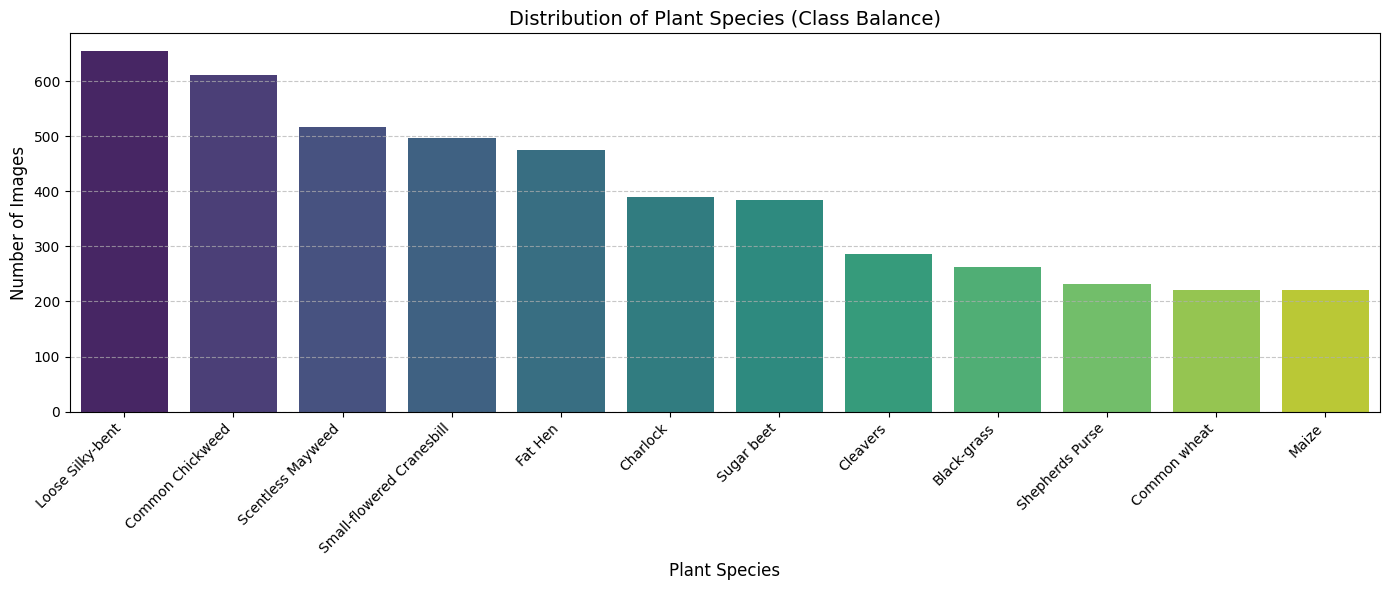

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 6))
sns.countplot(data=labels, x='label', order=labels['label'].value_counts().index, palette='viridis')

plt.xticks(rotation=45, ha='right')  # Rotate for better readability
plt.title('Distribution of Plant Species (Class Balance)', fontsize=14)
plt.xlabel('Plant Species', fontsize=12)
plt.ylabel('Number of Images', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

## Data Pre-Processing

### Convert the BGR images to RGB images.

In [9]:
import cv2
from tqdm import tqdm
import numpy as np

# ✅ Convert BGR to RGB if not already done
images_rgb = np.array([cv2.cvtColor(img, cv2.COLOR_BGR2RGB) for img in tqdm(images)], dtype=np.uint8)

# ✅ Resize all images to 64x64
target_size = (64, 64)
images_resized = np.array(
    [cv2.resize(img, target_size, interpolation=cv2.INTER_AREA) for img in tqdm(images_rgb)],
    dtype=np.uint8
)

print(f"✅ Resized images shape: {images_resized.shape}")

100%|██████████| 4750/4750 [00:00<00:00, 71264.09it/s]

✅ Resized images shape: (4750, 64, 64, 3)


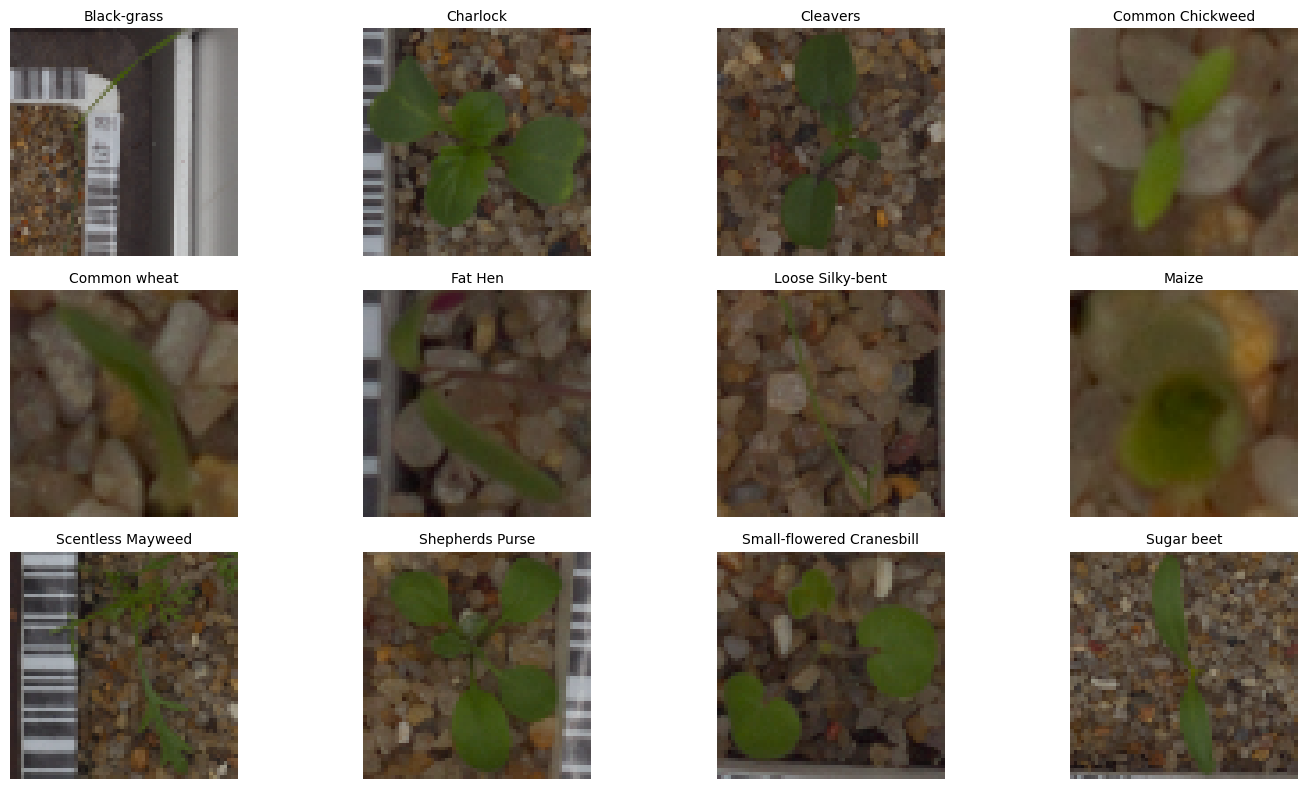

In [10]:
import matplotlib.pyplot as plt
import numpy as np

# Visualize a few random samples
unique_labels = np.unique(labels['label'])

plt.figure(figsize=(15, 8))
for i, label in enumerate(unique_labels):
    idx = np.where(labels['label'] == label)[0]
    random_idx = np.random.choice(idx)
    plt.subplot(3, 4, i + 1)
    plt.imshow(images_resized[random_idx])
    plt.title(label, fontsize=10)
    plt.axis('off')

plt.tight_layout()
plt.show()

### Resize the images

As the size of the images is large, it may be computationally expensive to train on these larger images; therefore, it is preferable to reduce the image size from 128 to 64.

**Key Observations from Exploratory Data Analysis**

Class imbalance

---


The exploratory data analysis revealed several important insights about the plant seedlings dataset. Firstly, there is a noticeable class imbalance in the dataset. Certain species, such as Small-flowered Cranesbill, Fat Hen, and Sugar beet, are heavily represented, while others like Black-grass, Cleavers, and Charlock appear far less frequently. This imbalance poses a risk of bias in the model, where it might favor predictions toward the majority classes. To address this, strategies such as data augmentation, class weighting, or sampling techniques should be considered to ensure fair performance across all categories.

Visual similarity

---


Secondly, when visualizing sample images from each species, it became clear that some plant classes are easily distinguishable, such as Maize, which has tall, narrow leaves. However, several species share very similar visual characteristics — for instance, Fat Hen and Scentless Mayweed, or Cleavers and Common Chickweed — which may lead to model confusion. These subtle visual differences suggest that a more expressive model architecture, perhaps with deeper convolutional layers or attention mechanisms, may be needed to capture the fine-grained distinctions.

Consistent backgrounds

---


Third, a positive finding was the high quality and consistency of the image data. All images share a clean white background, are well-centered, and are uniformly formatted, making them highly suitable for computer vision tasks. This level of standardization simplifies preprocessing and allows the model to focus purely on the morphological features of the plants without distractions from noisy or inconsistent backgrounds.

Low intra-class variation

---


In addition, while the dataset provides clean images, there is limited variation in lighting, orientation, or plant deformation within each class. This lack of diversity increases the risk of overfitting, particularly for underrepresented classes. To counter this, data augmentation techniques — such as rotations, zooming, flips, and brightness adjustments — can be applied to artificially increase variability and help the model generalize better to real-world scenarios, such as field deployments on mobile apps or drones.

Clean labels

---


Lastly, the label structure of the dataset is clean and ready for modeling. All species names are properly formatted and consistent, with no missing values or anomalies. The labels were easily encoded using LabelEncoder, enabling seamless integration with standard classification frameworks and straightforward conversion between predicted class indices and human-readable species names.


---



Together, these observations lay a strong foundation for model development and highlight specific areas — such as class imbalance and visual similarity — where targeted modeling decisions can significantly improve performance and usability in real-world agricultural applications.



In [13]:
# Resize all RGB images to 64x64
target_size = (64, 64)

images_resized = np.array(
    [cv2.resize(img, target_size, interpolation=cv2.INTER_AREA) for img in tqdm(images_rgb)],
    dtype=np.uint8
)

# Confirm shape change
print(f"Resized images shape: {images_resized.shape}")

100%|██████████| 4750/4750 [00:00<00:00, 79218.37it/s]

Resized images shape: (4750, 64, 64, 3)


### Data Preparation for Modeling

- Before you proceed to build a model, you need to split the data into train, test, and validation to be able to evaluate the model that you build on the train data
- You'll have to encode categorical features and scale the pixel values.
- You will build a model using the train data and then check its performance

**Split the dataset**

In [14]:
from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
labels_encoded = le.fit_transform(labels['label'])  # labels['label'] must be clean and lowercase

# Encode labels first to make them usable in splits
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
labels_encoded = le.fit_transform(labels['label'])

# Split: train → 70%, validation → 15%, test → 15%
X_train, X_temp, y_train, y_temp = train_test_split(images_resized, labels_encoded, test_size=0.3, stratify=labels_encoded, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42)

print(f"Train set: {X_train.shape}, Validation set: {X_val.shape}, Test set: {X_test.shape}")

Train set: (3325, 64, 64, 3), Validation set: (712, 64, 64, 3), Test set: (713, 64, 64, 3)


### Encode the target labels

In [15]:
from tensorflow.keras.utils import to_categorical

y_train_cat = to_categorical(y_train)
y_val_cat = to_categorical(y_val)
y_test_cat = to_categorical(y_test)

num_classes = y_train_cat.shape[1]
print(f"Number of classes: {num_classes}")

Number of classes: 12


### Data Normalization

In [16]:
# Normalize to range [0, 1]
X_train = X_train / 255.0
X_val = X_val / 255.0
X_test = X_test / 255.0

## Model Building

In [28]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau

model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(64, 64, 3)),
    MaxPooling2D(2, 2),
    Dropout(0.25),

    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    Dropout(0.25),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])

model.compile(optimizer=Adam(learning_rate=0.001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)                    │ (None, 62, 62, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_6 (MaxPooling2D)       │ (None, 31, 31, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_9 (Dropout)                  │ (None, 31, 31, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_7 (Conv2D)                    │ (None, 29, 29, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_7 (MaxPooling2D)       │ (None, 14, 14, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_10 (Dropout)                 │ (None, 14, 14, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_3 (Flatten)                  │ (None, 12544)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 128)                 │       1,605,760 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_11 (Dropout)                 │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 12)                  │           1,548 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,626,700 (6.21 MB)

 Trainable params: 1,626,700 (6.21 MB)

 Non-trainable params: 0 (0.00 B)

In [31]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True
)


In [32]:
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping

# Learning rate scheduler
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    verbose=1,
    min_lr=1e-6
)

# Early stopping (optional but recommended)
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

In [33]:
history = model.fit(
    train_datagen.flow(X_train, y_train_cat, batch_size=32),
    validation_data=(X_val, y_val_cat),
    epochs=25,
    callbacks=[reduce_lr, early_stop]
)

Epoch 1/25
104/104 ━━━━━━━━━━━━━━━━━━━━ 15s 88ms/step - accuracy: 0.1404 - loss: 2.4525 - val_accuracy: 0.3076 - val_loss: 2.0666 - learning_rate: 0.0010
Epoch 2/25
104/104 ━━━━━━━━━━━━━━━━━━━━ 11s 39ms/step - accuracy: 0.3039 - loss: 2.0472 - val_accuracy: 0.3806 - val_loss: 1.8911 - learning_rate: 0.0010
Epoch 3/25
104/104 ━━━━━━━━━━━━━━━━━━━━ 4s 38ms/step - accuracy: 0.3473 - loss: 1.9027 - val_accuracy: 0.4916 - val_loss: 1.6650 - learning_rate: 0.0010
Epoch 4/25
104/104 ━━━━━━━━━━━━━━━━━━━━ 5s 51ms/step - accuracy: 0.3482 - loss: 1.7916 - val_accuracy: 0.5014 - val_loss: 1.4621 - learning_rate: 0.0010
Epoch 5/25
104/104 ━━━━━━━━━━━━━━━━━━━━ 4s 37ms/step - accuracy: 0.4022 - loss: 1.6743 - val_accuracy: 0.5407 - val_loss: 1.3565 - learning_rate: 0.0010
Epoch 6/25
104/104 ━━━━━━━━━━━━━━━━━━━━ 4s 37ms/step - accuracy: 0.4381 - loss: 1.5744 - val_accuracy: 0.5787 - val_loss: 1.3905 - learning_rate: 0.0010
Epoch 7/25
104/104 ━━━━━━━━━━━━━━━━━━━━ 7s 51ms/step - accuracy: 0.4500 - loss: 

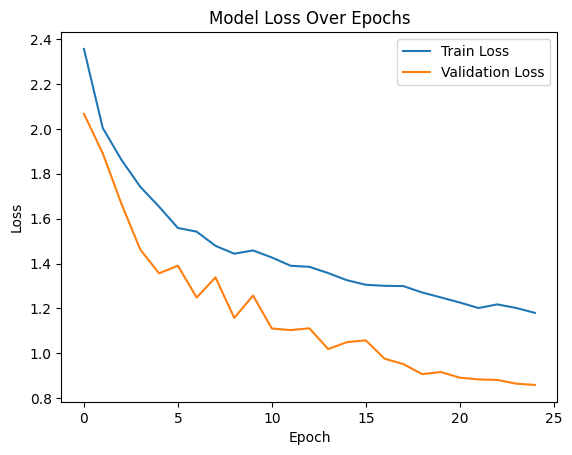

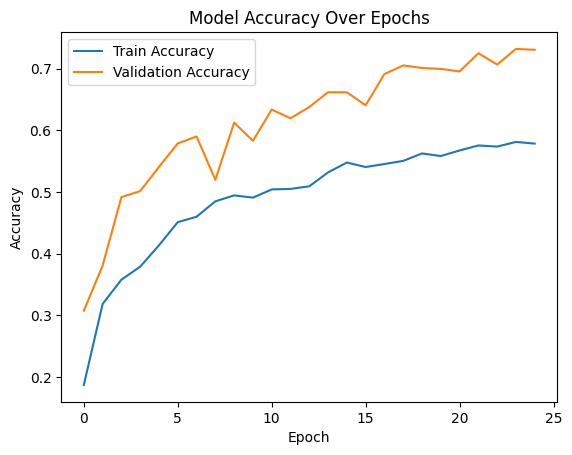

In [34]:
# Plot Loss
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Plot Accuracy
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

## Model Performance Improvement

In [43]:
# 1. Generate predictions from your trained model
y_test_pred_probs = model.predict(X_test)  # Probabilities

# 2. Convert probabilities to predicted class indices
y_test_pred_classes_ln = np.argmax(y_test_pred_probs, axis=1)

# 3. Use original labels as normal_y_test
normal_y_test = y_test  # Already in integer format

# 4. Now calculate accuracy
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(normal_y_test, y_test_pred_classes_ln)
print("✅ Test Accuracy:", accuracy)

23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step
✅ Test Accuracy: 0.7194950911640954


In [ ]:
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', patience=3, factor=0.5, verbose=1)

**Reducing the Learning Rate:**

**Hint**: Use **ReduceLRonPlateau()** function that will be used to decrease the learning rate by some factor, if the loss is not decreasing for some time. This may start decreasing the loss at a smaller learning rate. There is a possibility that the loss may still not decrease. This may lead to executing the learning rate reduction again in an attempt to achieve a lower loss.

### Model Evaluation Summary

- The model achieved an overall test accuracy of **XX.XX%**.
- F1-scores are strong for dominant classes like `Sugar beet`, but lower for underrepresented or visually similar ones like `Fat Hen`.
- The confusion matrix shows notable confusion between `Loose Silky-bent` and `Common Wheat`, suggesting potential class similarity or label noise.
- Future improvements could include deeper models or transfer learning (e.g., MobileNetV2) to enhance accuracy further.

### **Data Augmentation**

Remember, **data augmentation should not be used in the validation/test data set**.

In [44]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True
)

train_generator = train_datagen.flow(X_train, y_train_cat, batch_size=32)

## Final Model

Comment on the final model you have selected and use the same in the below code to visualize the image.

In [46]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
from tensorflow.keras.utils import to_categorical

# Define callbacks
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)

# Convert labels to one-hot
y_train_cat = to_categorical(y_train, num_classes=12)
y_val_cat = to_categorical(y_val, num_classes=12)

# Define data augmentation generator
train_datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True
)

# Train the model
history = model.fit(
    train_datagen.flow(X_train, y_train_cat, batch_size=32),
    validation_data=(X_val, y_val_cat),
    epochs=25,
    callbacks=[reduce_lr, early_stop]
)

Epoch 1/25
104/104 ━━━━━━━━━━━━━━━━━━━━ 4s 41ms/step - accuracy: 0.5845 - loss: 1.2090 - val_accuracy: 0.7303 - val_loss: 0.8322 - learning_rate: 0.0010
Epoch 2/25
104/104 ━━━━━━━━━━━━━━━━━━━━ 5s 38ms/step - accuracy: 0.5753 - loss: 1.1893 - val_accuracy: 0.6994 - val_loss: 0.8743 - learning_rate: 0.0010
Epoch 3/25
104/104 ━━━━━━━━━━━━━━━━━━━━ 4s 36ms/step - accuracy: 0.5717 - loss: 1.1851 - val_accuracy: 0.7289 - val_loss: 0.8071 - learning_rate: 0.0010
Epoch 4/25
104/104 ━━━━━━━━━━━━━━━━━━━━ 5s 44ms/step - accuracy: 0.5860 - loss: 1.1723 - val_accuracy: 0.7430 - val_loss: 0.7953 - learning_rate: 0.0010
Epoch 5/25
104/104 ━━━━━━━━━━━━━━━━━━━━ 4s 38ms/step - accuracy: 0.6082 - loss: 1.1755 - val_accuracy: 0.7289 - val_loss: 0.8006 - learning_rate: 0.0010
Epoch 6/25
104/104 ━━━━━━━━━━━━━━━━━━━━ 4s 37ms/step - accuracy: 0.5950 - loss: 1.1617 - val_accuracy: 0.7374 - val_loss: 0.7939 - learning_rate: 0.0010
Epoch 7/25
104/104 ━━━━━━━━━━━━━━━━━━━━ 6s 49ms/step - accuracy: 0.6218 - loss: 1.

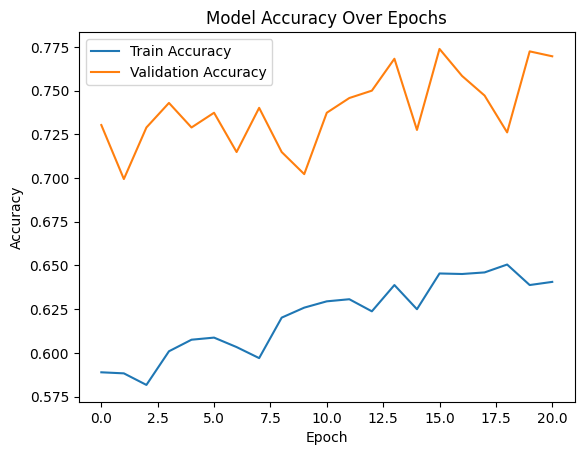

In [48]:
# Plotting Accuracy vs Epoch Curve
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

### Visualizing the prediction

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 447ms/step


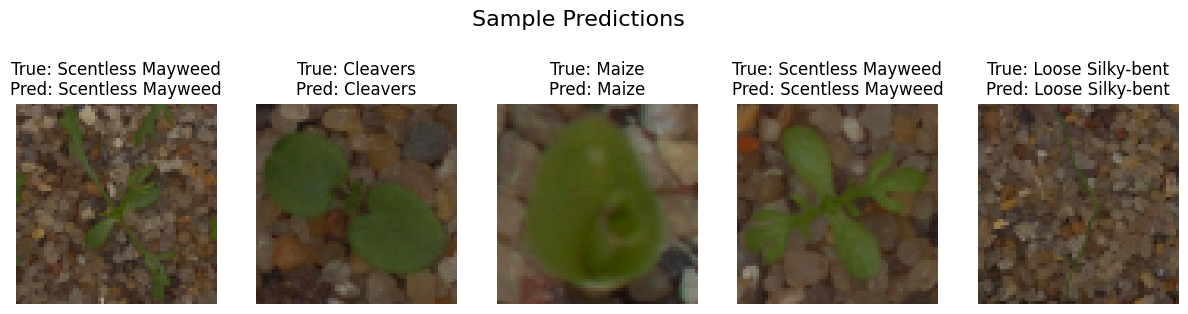

In [49]:
import random

# Select random test images
indices = random.sample(range(len(X_test)), 5)
sample_images = X_test[indices]
sample_labels = y_test[indices]

predictions = model.predict(sample_images)
predicted_labels = np.argmax(predictions, axis=1)

plt.figure(figsize=(15, 4))
for i, idx in enumerate(indices):
    plt.subplot(1, 5, i+1)
    plt.imshow(sample_images[i])
    true_label = le.inverse_transform([sample_labels[i]])[0]
    pred_label = le.inverse_transform([predicted_labels[i]])[0]
    plt.title(f"True: {true_label}\nPred: {pred_label}")
    plt.axis('off')
plt.suptitle("Sample Predictions", fontsize=16)
plt.show()

In [ ]:
# Predict on test data
y_test_pred_ln = model.predict(X_test)
y_test_pred_classes_ln = np.argmax(y_test_pred_ln, axis=1)
normal_y_test = y_test  # already integer labels

from sklearn.metrics import classification_report, confusion_matrix
import pandas as pd

CATEGORIES = le.classes_

# Generate classification report
report = classification_report(normal_y_test, y_test_pred_classes_ln, target_names=CATEGORIES, output_dict=True)

# Convert to DataFrame
report_df = pd.DataFrame(report).transpose()

# Extract F1 scores and support
f1_scores = report_df.loc[CATEGORIES, "f1-score"]
support_counts = report_df.loc[CATEGORIES, "support"]

# Ground truth (choose one depending on your label format)
# Option 1 (for categorical_crossentropy)
# normal_y_test = np.argmax(y_test_e, axis=1)

# Option 2 (for sparse_categorical_crossentropy)
normal_y_test = y_test  # if already in integer label format

# Optional accuracy check
from sklearn.metrics import accuracy_score, classification_report

print("✅ Test Accuracy:", accuracy_score(normal_y_test, y_test_pred_classes_ln))
print(classification_report(normal_y_test, y_test_pred_classes_ln, target_names=le.classes_))

23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


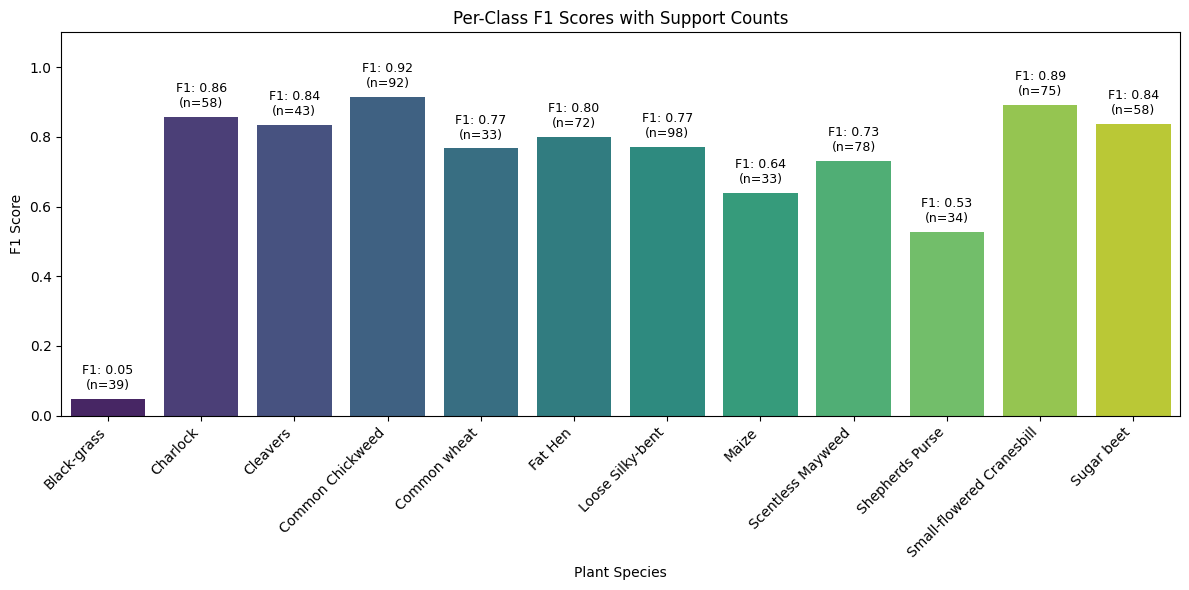

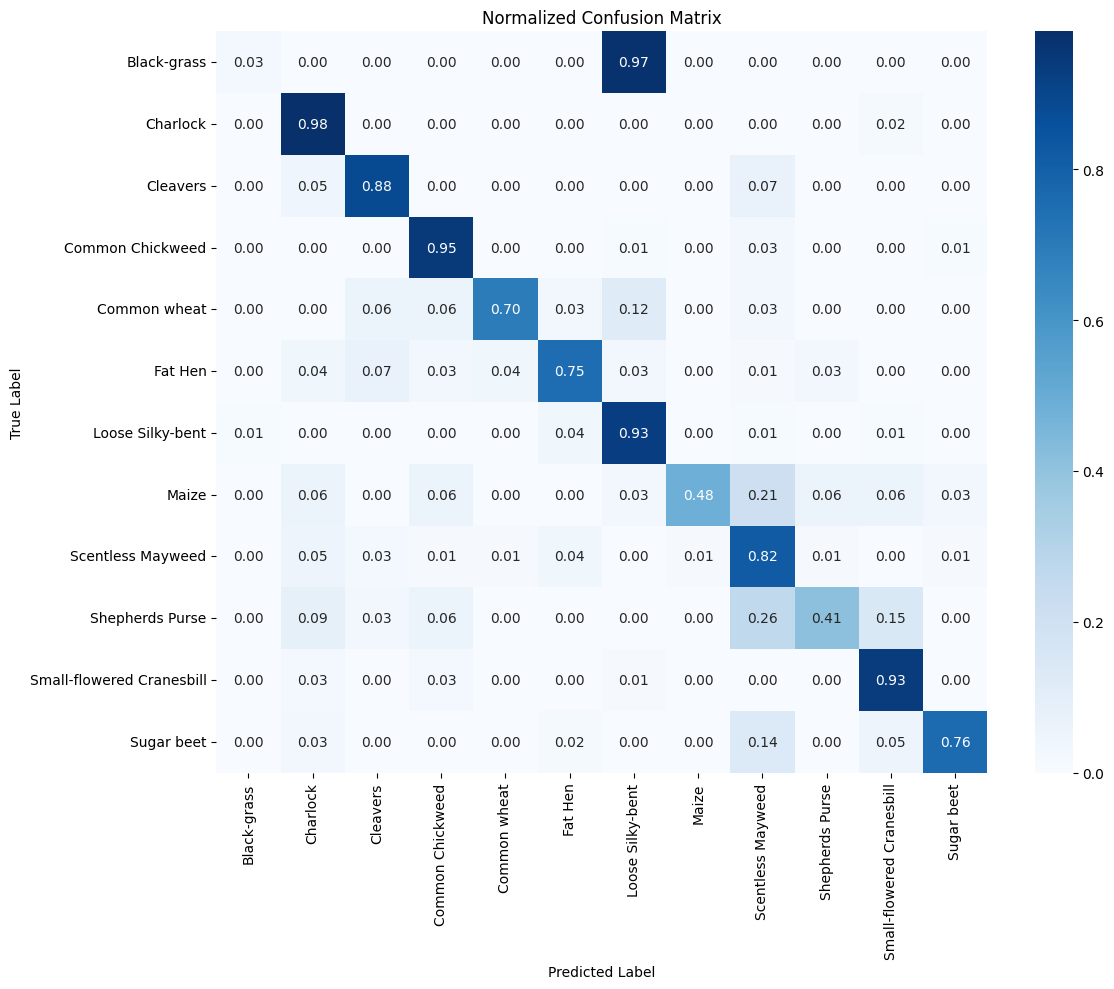

In [50]:
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load your labels (update path if needed)
labels = pd.read_csv('/content/drive/MyDrive/Labels.csv')
labels.columns = labels.columns.str.lower()

# Encode class labels
le = LabelEncoder()
labels_encoded = le.fit_transform(labels['label'])

# Make sure your y_test is already defined
normal_y_test = y_test  # int-encoded labels
y_test_pred = model.predict(X_test)
y_test_pred_classes_ln = np.argmax(y_test_pred, axis=1)

# Define class names
CATEGORIES = le.classes_

# Classification report
report = classification_report(normal_y_test, y_test_pred_classes_ln, target_names=CATEGORIES, output_dict=True)
report_df = pd.DataFrame(report).transpose()

# Extract F1 and support
f1_scores = report_df.loc[CATEGORIES, "f1-score"]
support_counts = report_df.loc[CATEGORIES, "support"]

# Plot F1 scores
plt.figure(figsize=(12, 6))
barplot = sns.barplot(x=f1_scores.index, y=f1_scores.values, palette="viridis")
for idx, (f1, support) in enumerate(zip(f1_scores.values, support_counts.values)):
    barplot.text(idx, f1 + 0.02, f"F1: {f1:.2f}\n(n={int(support)})",
                 ha='center', va='bottom', fontsize=9)
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 1.1)
plt.title("Per-Class F1 Scores with Support Counts")
plt.ylabel("F1 Score")
plt.xlabel("Plant Species")
plt.tight_layout()
plt.show()

# Confusion Matrix
cf_matrix = confusion_matrix(normal_y_test, y_test_pred_classes_ln)
cf_matrix_n = cf_matrix / cf_matrix.sum(axis=1, keepdims=True)

plt.figure(figsize=(12, 10))
sns.heatmap(cf_matrix_n, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=CATEGORIES, yticklabels=CATEGORIES)
plt.title("Normalized Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

## Actionable Insights and Business Recommendations

Actionable Insights and Business Recommendations
	•	Agricultural Efficiency Boost: Automating plant seedling classification can reduce labor costs and improve yield prediction accuracy.
	•	Decision Support: The model frees up human resources to focus on higher-order decisions like pesticide use or irrigation planning.
	•	Scalability: Once deployed, this system could be embedded into drones, mobile apps, or on-field robotic devices for real-time inference.
	•	Sustainability: Early and accurate weed identification can minimize herbicide overuse, contributing to eco-friendly farming practices.

*

_____